In [3]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

dataset = fetch_ucirepo(id=601)

X = dataset.data.features
y = dataset.data.targets

df = pd.concat([X, y], axis=1)

df.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
df.shape

(10000, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  str    
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Torque               10000 non-null  float64
 5   Tool wear            10000 non-null  int64  
 6   Machine failure      10000 non-null  int64  
 7   TWF                  10000 non-null  int64  
 8   HDF                  10000 non-null  int64  
 9   PWF                  10000 non-null  int64  
 10  OSF                  10000 non-null  int64  
 11  RNF                  10000 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 947.4 KB


In [6]:
df.describe()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [7]:
df.columns.tolist()

['Type',
 'Air temperature',
 'Process temperature',
 'Rotational speed',
 'Torque',
 'Tool wear',
 'Machine failure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF']

## 2. Data Quality Analysis

In [8]:
df.isnull().sum()

Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Torque                 0
Tool wear              0
Machine failure        0
TWF                    0
HDF                    0
PWF                    0
OSF                    0
RNF                    0
dtype: int64

In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

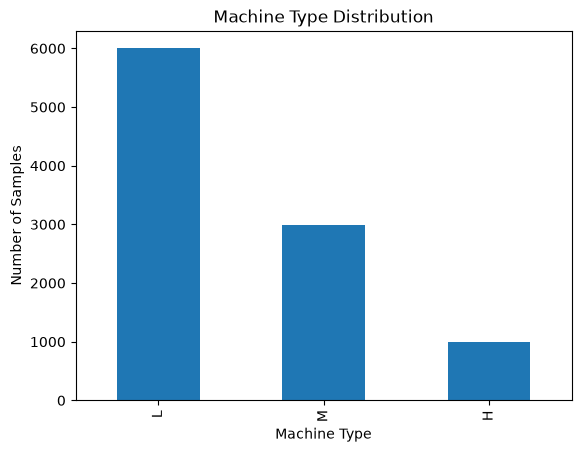

In [12]:
import matplotlib.pyplot as plt

df["Type"].value_counts().plot(kind="bar")

plt.title("Machine Type Distribution")
plt.xlabel("Machine Type")
plt.ylabel("Number of Samples")
plt.show()

In [13]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [14]:
df["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

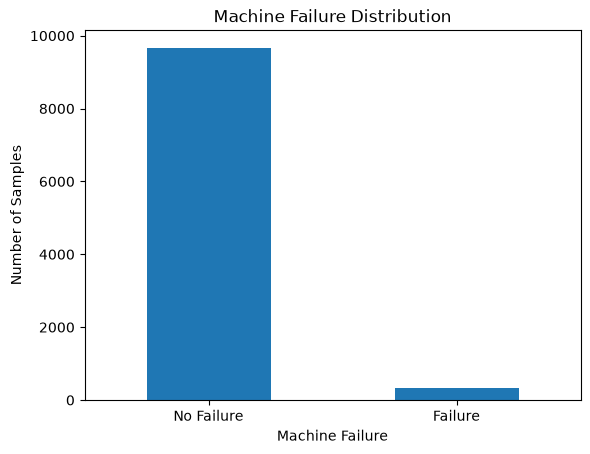

In [15]:
df["Machine failure"].value_counts().plot(
    kind="bar"
)

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Number of Samples")
plt.xticks(
    ticks=[0, 1],
    labels=["No Failure", "Failure"],
    rotation=0
)

plt.show()

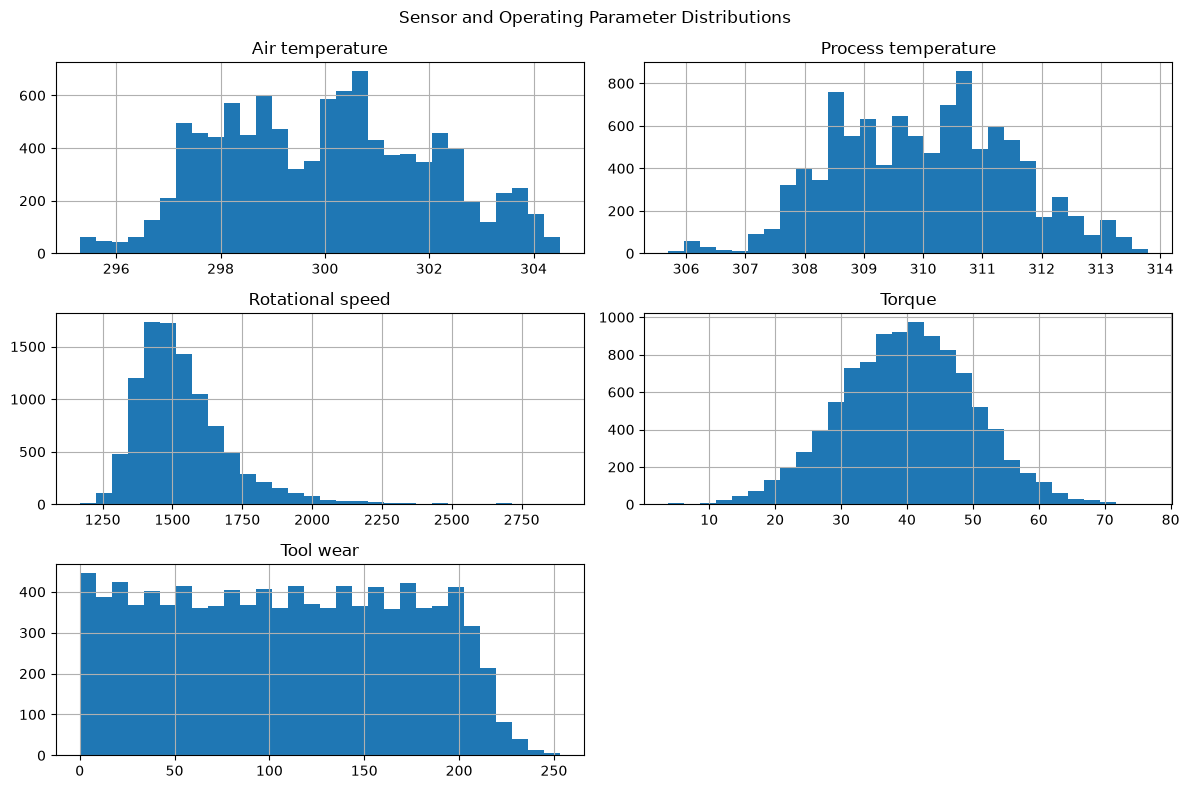

In [16]:
numeric_columns = [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear"
]

df[numeric_columns].hist(
    figsize=(12, 8),
    bins=30
)

plt.suptitle("Sensor and Operating Parameter Distributions")
plt.tight_layout()
plt.show()

In [17]:
df.groupby("Machine failure")[numeric_columns].mean()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


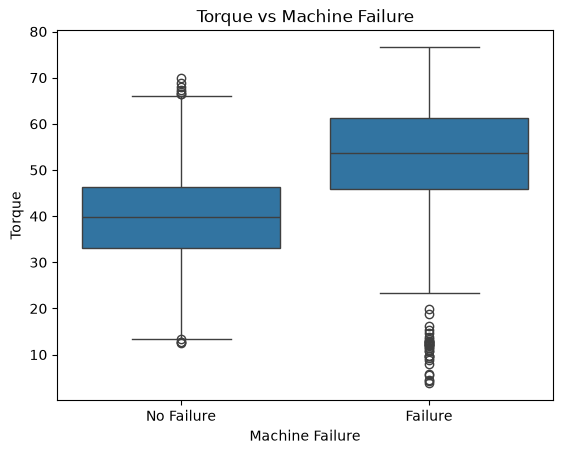

In [18]:
import seaborn as sns

sns.boxplot(
    data=df,
    x="Machine failure",
    y="Torque"
)

plt.title("Torque vs Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Torque")
plt.xticks(
    [0, 1],
    ["No Failure", "Failure"]
)

plt.show()

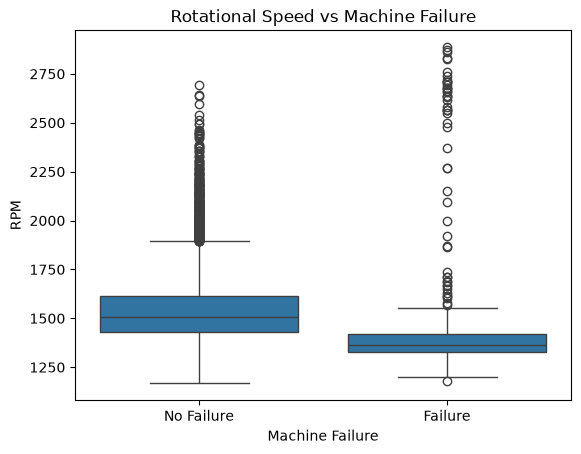

In [19]:
sns.boxplot(
    data=df,
    x="Machine failure",
    y="Rotational speed"
)

plt.title("Rotational Speed vs Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("RPM")
plt.xticks(
    [0, 1],
    ["No Failure", "Failure"]
)

plt.show()

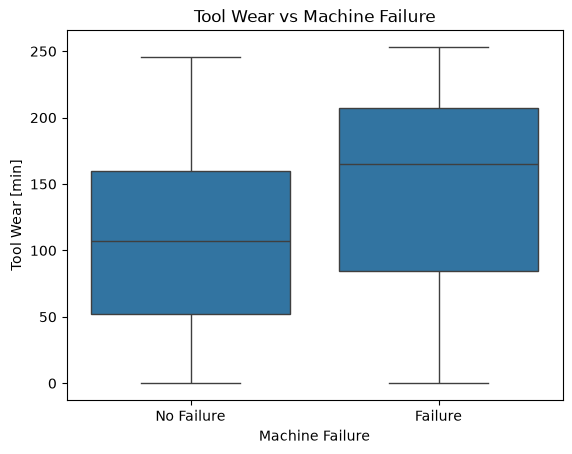

In [20]:
sns.boxplot(
    data=df,
    x="Machine failure",
    y="Tool wear"
)

plt.title("Tool Wear vs Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Tool Wear [min]")
plt.xticks(
    [0, 1],
    ["No Failure", "Failure"]
)

plt.show()

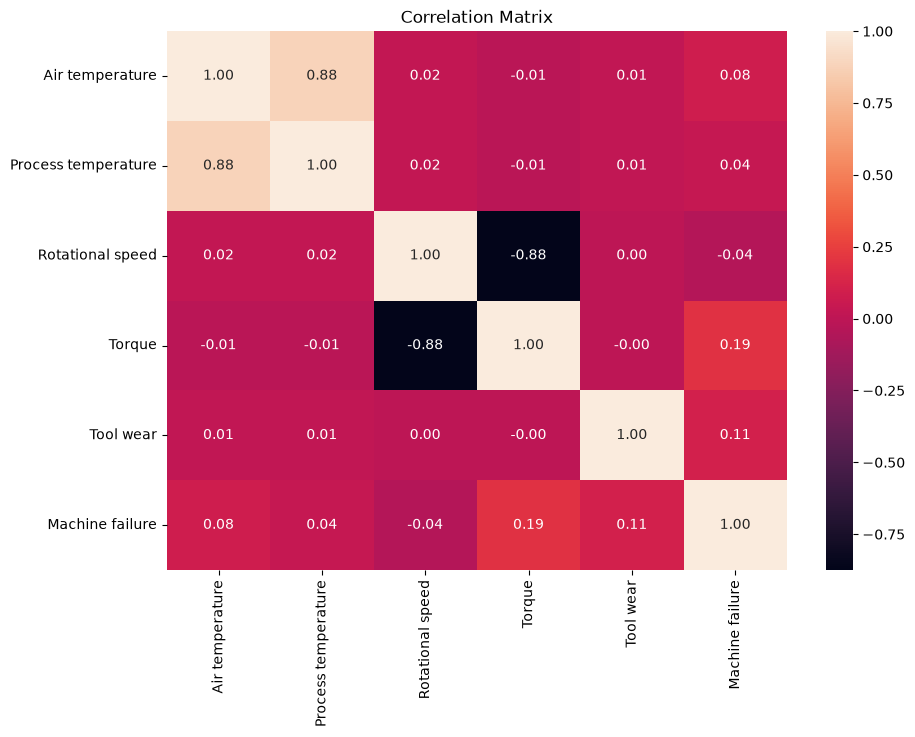

In [21]:
correlation = df[numeric_columns + ["Machine failure"]].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [22]:
failure_types = ["TWF", "HDF", "PWF", "OSF", "RNF"]

df[failure_types].sum().sort_values(ascending=False)

HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64

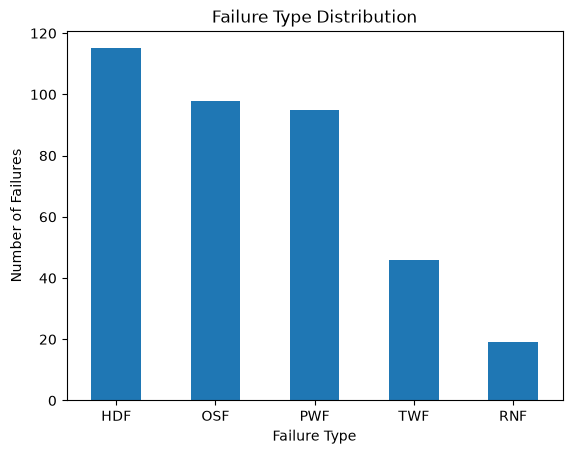

In [23]:
df[failure_types].sum().sort_values(ascending=False).plot(
    kind="bar"
)

plt.title("Failure Type Distribution")
plt.xlabel("Failure Type")
plt.ylabel("Number of Failures")
plt.xticks(rotation=0)

plt.show()

In [24]:
df.isnull().sum()

Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Torque                 0
Tool wear              0
Machine failure        0
TWF                    0
HDF                    0
PWF                    0
OSF                    0
RNF                    0
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [27]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [28]:
df["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [29]:
df.groupby("Machine failure")[numeric_columns].mean()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


## 3. Feature Engineering

Feature 1 — Temperature difference

In [30]:
df["Temperature Difference"] = (
    df["Process temperature"] - df["Air temperature"]
)

In [31]:
df["Temperature Difference"].describe()

count    10000.000000
mean        10.000630
std          1.001094
min          7.600000
25%          9.300000
50%          9.800000
75%         11.000000
max         12.100000
Name: Temperature Difference, dtype: float64

Feature 2 — Mechanical power

In [32]:
import numpy as np

df["Mechanical Power"] = (
    df["Torque"] *
    (2 * np.pi * df["Rotational speed"] / 60)
)

In [33]:
df["Mechanical Power kW"] = (
    df["Mechanical Power"] / 1000
)

In [34]:
df[
    [
        "Torque",
        "Rotational speed",
        "Mechanical Power kW"
    ]
].head()

,Torque,Rotational speed,Mechanical Power kW
0,42.8,1551,6.951591
1,46.3,1408,6.826723
2,49.4,1498,7.749388
3,39.5,1433,5.927505
4,40.0,1408,5.897817


Feature 3 — Temperature ratio

In [35]:
df["Temperature Ratio"] = (
    df["Process temperature"] /
    df["Air temperature"]
)

In [36]:
feature_columns = [
    "Type",
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear",
    "Temperature Difference",
    "Mechanical Power kW",
    "Temperature Ratio"
]

target_column = "Machine failure"

In [37]:
X = df[feature_columns]
y = df[target_column]

In [38]:
X.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Temperature Difference,Mechanical Power kW,Temperature Ratio
0,M,298.1,308.6,1551,42.8,0,10.5,6.951591,1.035223
1,L,298.2,308.7,1408,46.3,3,10.5,6.826723,1.035211
2,L,298.1,308.5,1498,49.4,5,10.4,7.749388,1.034888
3,L,298.2,308.6,1433,39.5,7,10.4,5.927505,1.034876
4,L,298.2,308.7,1408,40.0,9,10.5,5.897817,1.035211


In [39]:
y.value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [41]:
print("Training set:")
print(y_train.value_counts())

print("\nTest set:")
print(y_test.value_counts())

Training set:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Test set:
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [42]:
df["Temperature Difference"] = (
    df["Process temperature"] - df["Air temperature"]
)

df["Mechanical Power"] = (
    df["Torque"] *
    (2 * np.pi * df["Rotational speed"] / 60)
)

df["Mechanical Power kW"] = (
    df["Mechanical Power"] / 1000
)

df["Temperature Ratio"] = (
    df["Process temperature"] /
    df["Air temperature"]
)

In [43]:
feature_columns = [
    "Type",
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear",
    "Temperature Difference",
    "Mechanical Power kW",
    "Temperature Ratio"
]

target_column = "Machine failure"

X = df[feature_columns]
y = df[target_column]

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
df[
    [
        "Temperature Difference",
        "Mechanical Power kW",
        "Temperature Ratio"
    ]
].describe()

,Temperature Difference,Mechanical Power kW,Temperature Ratio
count,10000.000000,10000.000000,10000.000000
mean,10.000630,6.279745,1.033352
std,1.001094,1.067418,0.003492
min,7.600000,1.148441,1.025116
25%,9.300000,5.561184,1.030686
50%,9.800000,6.271027,1.032847
75%,11.000000,7.003003,1.036777
max,12.100000,10.469923,1.040672


In [46]:
print(X_train.shape)
print(X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTest target:")
print(y_test.value_counts())

(8000, 9)
(2000, 9)

Training target:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Test target:
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [48]:
categorical_features = ["Type"]

numerical_features = [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear",
    "Temperature Difference",
    "Mechanical Power kW",
    "Temperature Ratio"
]

In [49]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [51]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [52]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Type','Air temperature','Process temperature',..., 'Temperature Difference','Mechanical Power kW','Temperature Ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop

In [53]:
y_pred = logistic_model.predict(X_test)

In [54]:
y_proba = logistic_model.predict_proba(X_test)[:, 1]

In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [56]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba))
print("PR-AUC   :", average_precision_score(y_test, y_proba))

Accuracy : 0.859
Precision: 0.17771084337349397
Recall   : 0.8676470588235294
F1 Score : 0.295
ROC-AUC  : 0.9340062111801242
PR-AUC   : 0.4661818410305121


In [57]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      1932
           1       0.18      0.87      0.29        68

    accuracy                           0.86      2000
   macro avg       0.59      0.86      0.61      2000
weighted avg       0.97      0.86      0.90      2000



In [58]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1659  273]
 [   9   59]]


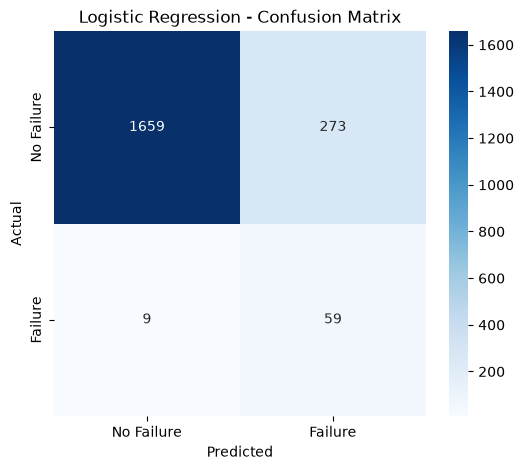

In [59]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [60]:
logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
    "PR-AUC": average_precision_score(y_test, y_proba)
}

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.859,
 'Precision': 0.17771084337349397,
 'Recall': 0.8676470588235294,
 'F1': 0.295,
 'ROC-AUC': 0.9340062111801242,
 'PR-AUC': 0.4661818410305121}

In [61]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba))
print("PR-AUC   :", average_precision_score(y_test, y_proba))

Accuracy : 0.859
Precision: 0.17771084337349397
Recall   : 0.8676470588235294
F1 Score : 0.295
ROC-AUC  : 0.9340062111801242
PR-AUC   : 0.4661818410305121


In [62]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      1932
           1       0.18      0.87      0.29        68

    accuracy                           0.86      2000
   macro avg       0.59      0.86      0.61      2000
weighted avg       0.97      0.86      0.90      2000



In [63]:
print(confusion_matrix(y_test, y_pred))

[[1659  273]
 [   9   59]]


In [64]:
logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.859,
 'Precision': 0.17771084337349397,
 'Recall': 0.8676470588235294,
 'F1': 0.295,
 'ROC-AUC': 0.9340062111801242,
 'PR-AUC': 0.4661818410305121}

## 5. Random Forest

In [65]:
from sklearn.ensemble import RandomForestClassifier

In [66]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [67]:
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Type','Air temperature','Process temperature',..., 'Temperature Difference','Mechanical Power kW','Temperature Ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop

In [68]:
rf_pred = random_forest_model.predict(X_test)

rf_proba = random_forest_model.predict_proba(X_test)[:, 1]

In [69]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_proba)
rf_pr_auc = average_precision_score(y_test, rf_proba)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_roc_auc)
print("PR-AUC   :", rf_pr_auc)

Random Forest Results
---------------------
Accuracy : 0.9895
Precision: 0.8983050847457628
Recall   : 0.7794117647058824
F1 Score : 0.8346456692913385
ROC-AUC  : 0.9741543356473024
PR-AUC   : 0.8576924780795031


In [70]:
print(classification_report(y_test, rf_pred))   

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.90      0.78      0.83        68

    accuracy                           0.99      2000
   macro avg       0.95      0.89      0.91      2000
weighted avg       0.99      0.99      0.99      2000



In [71]:
rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[1926    6]
 [  15   53]]


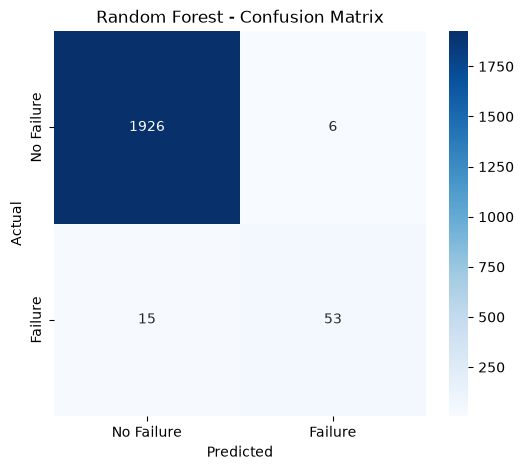

In [72]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [73]:
results = pd.DataFrame([
    logistic_results,
    {
        "Model": "Random Forest",
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1": rf_f1,
        "ROC-AUC": rf_roc_auc,
        "PR-AUC": rf_pr_auc
    }
])

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.8590,0.177711,0.867647,0.295000,0.934006,0.466182
1,Random Forest,0.9895,0.898305,0.779412,0.834646,0.974154,0.857692


In [74]:
rf_preprocessor = random_forest_model.named_steps["preprocessor"]

feature_names = rf_preprocessor.get_feature_names_out()

rf_classifier = random_forest_model.named_steps["classifier"]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,num__Tool wear,0.208849
2,num__Rotational speed,0.203429
6,num__Mechanical Power kW,0.197354
3,num__Torque,0.193036
7,num__Temperature Ratio,0.074897
5,num__Temperature Difference,0.047610
0,num__Air temperature,0.035274
1,num__Process temperature,0.025561
9,cat__Type_L,0.006790
10,cat__Type_M,0.004801


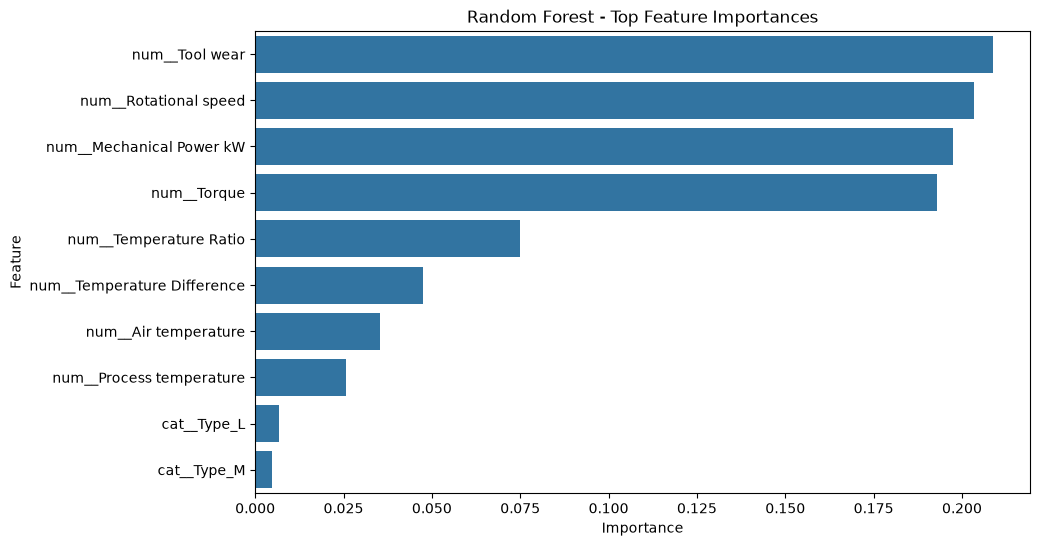

In [75]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Random Forest - Top Feature Importances")

plt.show()  

## 6. XGBoost

In [76]:
from xgboost import XGBClassifier

In [77]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Negative samples:", negative)
print("Positive samples:", positive)
print("Scale pos weight:", scale_pos_weight)

Negative samples: 7729
Positive samples: 271
Scale pos weight: 28.52029520295203


In [78]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [79]:
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Type','Air temperature','Process temperature',..., 'Temperature Difference','Mechanical Power kW','Temperature Ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop

In [80]:
xgb_pred = xgb_model.predict(X_test)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

In [81]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_proba)
xgb_pr_auc = average_precision_score(y_test, xgb_proba)

print("XGBoost Results")
print("----------------")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)
print("ROC-AUC  :", xgb_roc_auc)
print("PR-AUC   :", xgb_pr_auc)

XGBoost Results
----------------
Accuracy : 0.982
Precision: 0.686046511627907
Recall   : 0.8676470588235294
F1 Score : 0.7662337662337663
ROC-AUC  : 0.9788850322737791
PR-AUC   : 0.884490164538603


In [82]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1932
           1       0.69      0.87      0.77        68

    accuracy                           0.98      2000
   macro avg       0.84      0.93      0.88      2000
weighted avg       0.98      0.98      0.98      2000



In [83]:
xgb_cm = confusion_matrix(y_test, xgb_pred)

print(xgb_cm)

[[1905   27]
 [   9   59]]


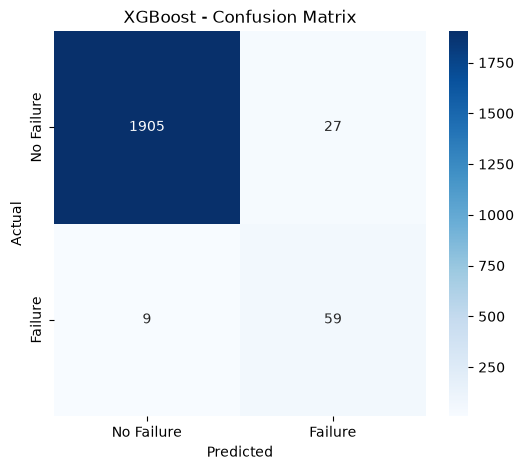

In [84]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [85]:
xgb_results = {
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1": xgb_f1,
    "ROC-AUC": xgb_roc_auc,
    "PR-AUC": xgb_pr_auc
}

results = pd.DataFrame([
    logistic_results,
    {
        "Model": "Random Forest",
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1": rf_f1,
        "ROC-AUC": rf_roc_auc,
        "PR-AUC": rf_pr_auc
    },
    xgb_results
])

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.8590,0.177711,0.867647,0.295000,0.934006,0.466182
1,Random Forest,0.9895,0.898305,0.779412,0.834646,0.974154,0.857692
2,XGBoost,0.9820,0.686047,0.867647,0.766234,0.978885,0.884490


## 7. Prediction Threshold Optimization

In [86]:
xgb_proba

array([0.29487422, 0.00056896, 0.4369784 , ..., 0.00064768, 0.02295138,
       0.00167958], shape=(2000,), dtype=float32)

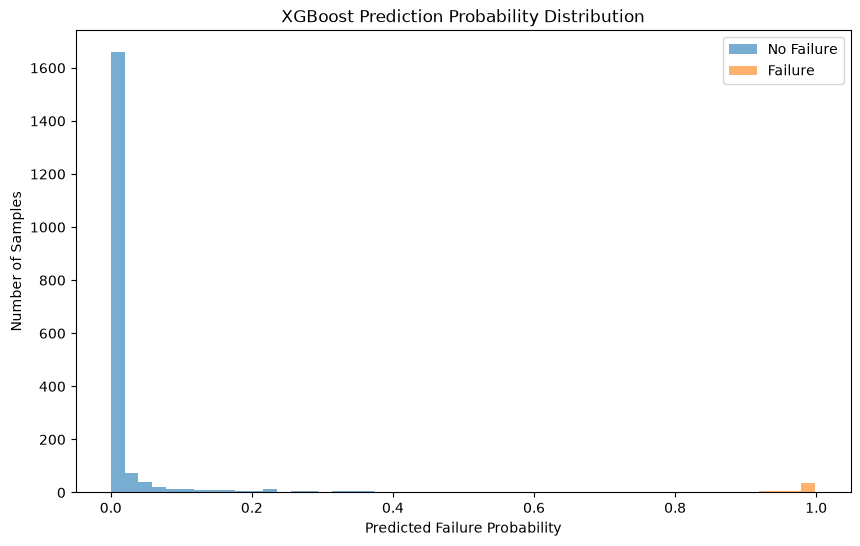

In [87]:
plt.figure(figsize=(10, 6))

plt.hist(
    xgb_proba[y_test.values == 0],
    bins=50,
    alpha=0.6,
    label="No Failure"
)

plt.hist(
    xgb_proba[y_test.values == 1],
    bins=50,
    alpha=0.6,
    label="Failure"
)

plt.xlabel("Predicted Failure Probability")
plt.ylabel("Number of Samples")
plt.title("XGBoost Prediction Probability Distribution")
plt.legend()

plt.show()

In [88]:
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    predictions = (xgb_proba >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df    

,Threshold,Precision,Recall,F1
0,0.10,0.333333,0.926471,0.490272
1,0.15,0.381818,0.926471,0.540773
2,0.20,0.434483,0.926471,0.591549
3,0.25,0.492188,0.926471,0.642857
4,0.30,0.535088,0.897059,0.670330
5,0.35,0.576923,0.882353,0.697674
6,0.40,0.631579,0.882353,0.736196
7,0.45,0.662921,0.867647,0.751592
8,0.50,0.686047,0.867647,0.766234
9,0.55,0.694118,0.867647,0.771242


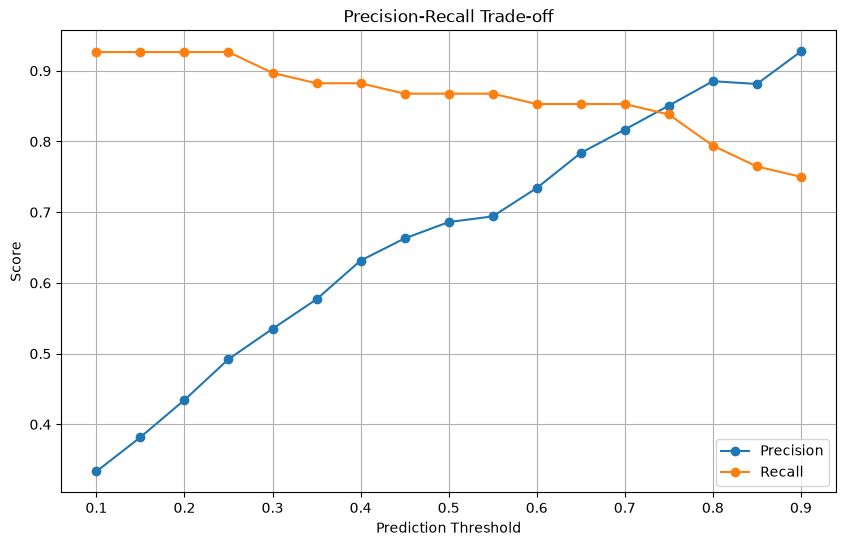

In [89]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Prediction Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off")
plt.legend()
plt.grid(True)

plt.show()

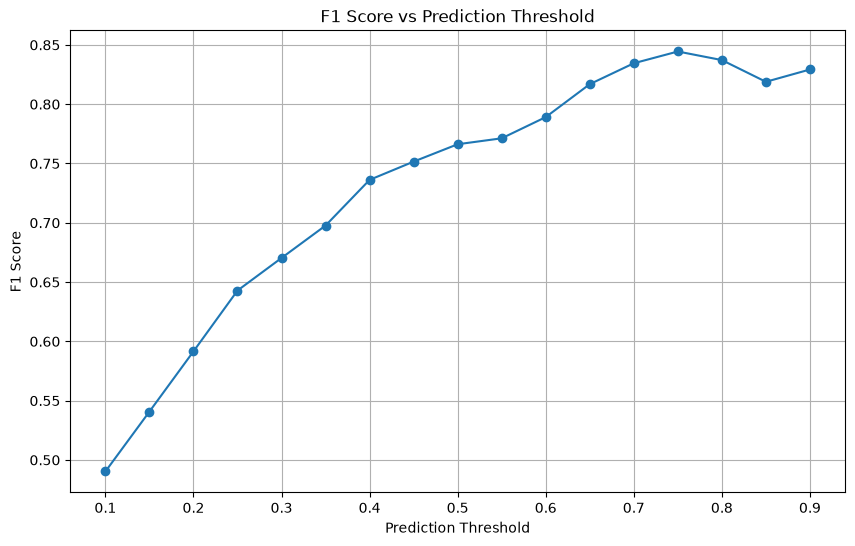

In [90]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o"
)

plt.xlabel("Prediction Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Prediction Threshold")
plt.grid(True)

plt.show()

In [91]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold_row

Threshold    0.750000
Precision    0.850746
Recall       0.838235
F1           0.844444
Name: 13, dtype: float64

## 8. Validation Strategy

In [92]:
X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [93]:
print("Model training:", X_train_model.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTraining failures:")
print(y_train_model.value_counts())

print("\nValidation failures:")
print(y_val.value_counts())

print("\nTest failures:")
print(y_test.value_counts())

Model training: (6400, 9)
Validation: (1600, 9)
Test: (2000, 9)

Training failures:
Machine failure
0    6183
1     217
Name: count, dtype: int64

Validation failures:
Machine failure
0    1546
1      54
Name: count, dtype: int64

Test failures:
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [94]:
negative = (y_train_model == 0).sum()
positive = (y_train_model == 1).sum()

scale_pos_weight = negative / positive

print("Scale pos weight:", scale_pos_weight)

Scale pos weight: 28.493087557603687


In [95]:
xgb_validation_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [96]:
xgb_validation_model.fit(
    X_train_model,
    y_train_model
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Type','Air temperature','Process temperature',..., 'Temperature Difference','Mechanical Power kW','Temperature Ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop

In [97]:
val_proba = xgb_validation_model.predict_proba(
    X_val
)[:, 1]

In [98]:
thresholds = np.arange(0.10, 0.91, 0.05)

validation_threshold_results = []

for threshold in thresholds:

    predictions = (
        val_proba >= threshold
    ).astype(int)

    validation_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_val,
            predictions,
            zero_division=0
        )
    })

validation_threshold_df = pd.DataFrame(
    validation_threshold_results
)

validation_threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.328859,0.907407,0.482759
1,0.15,0.398305,0.870370,0.546512
2,0.20,0.460784,0.870370,0.602564
3,0.25,0.511364,0.833333,0.633803
4,0.30,0.578947,0.814815,0.676923
5,0.35,0.605634,0.796296,0.688000
6,0.40,0.661538,0.796296,0.722689
7,0.45,0.716667,0.796296,0.754386
8,0.50,0.741379,0.796296,0.767857
9,0.55,0.763636,0.777778,0.770642


In [99]:
best_validation_threshold = validation_threshold_df.loc[
    validation_threshold_df["F1"].idxmax()
]

best_validation_threshold

Threshold    0.600000
Precision    0.807692
Recall       0.777778
F1           0.792453
Name: 10, dtype: float64

In [100]:
final_test_proba = xgb_validation_model.predict_proba(
    X_test
)[:, 1]

In [101]:
selected_threshold = best_validation_threshold["Threshold"]

final_test_pred = (
    final_test_proba >= selected_threshold
).astype(int)

In [102]:
final_accuracy = accuracy_score(
    y_test,
    final_test_pred
)

final_precision = precision_score(
    y_test,
    final_test_pred
)

final_recall = recall_score(
    y_test,
    final_test_pred
)

final_f1 = f1_score(
    y_test,
    final_test_pred
)

final_roc_auc = roc_auc_score(
    y_test,
    final_test_proba
)

final_pr_auc = average_precision_score(
    y_test,
    final_test_proba
)

print("FINAL XGBOOST MODEL")
print("-------------------")
print("Threshold:", selected_threshold)
print("Accuracy :", final_accuracy)
print("Precision:", final_precision)
print("Recall   :", final_recall)
print("F1 Score :", final_f1)
print("ROC-AUC  :", final_roc_auc)
print("PR-AUC   :", final_pr_auc)

FINAL XGBOOST MODEL
-------------------
Threshold: 0.6000000000000002
Accuracy : 0.986
Precision: 0.7777777777777778
Recall   : 0.8235294117647058
F1 Score : 0.8
ROC-AUC  : 0.9719964072585556
PR-AUC   : 0.8606637569009561


## 9. XGBoost Hyperparameter Tuning

In [103]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

In [104]:
xgb_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                n_jobs=1
            )
        )
    ]
)

In [105]:
param_distributions = {
    "classifier__n_estimators": [
        200,
        300,
        400,
        500
    ],

    "classifier__max_depth": [
        2,
        3,
        4,
        5,
        6
    ],

    "classifier__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.08,
        0.1
    ],

    "classifier__min_child_weight": [
        1,
        3,
        5,
        7
    ],

    "classifier__subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "classifier__colsample_bytree": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "classifier__gamma": [
        0,
        0.1,
        0.3,
        0.5
    ],

    "classifier__reg_alpha": [
        0,
        0.01,
        0.1,
        0.5
    ],

    "classifier__reg_lambda": [
        1,
        2,
        5,
        10
    ]
}

In [106]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [107]:
random_search = RandomizedSearchCV(
    estimator=xgb_tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="average_precision",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    refit=True
)

In [108]:
random_search.fit(
    X_train_model,
    y_train_model
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': [0.7, 0.8, ...], 'classifier__gamma': [0, 0.1, ...], 'classifier__learning_rate': [0.01, 0.03, ...], 'classifier__max_depth': [2, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than 

In [109]:
print("Best CV PR-AUC:")
print(random_search.best_score_)

Best CV PR-AUC:
0.8580078781192828


In [110]:
print("\nBest Parameters:")
print(random_search.best_params_)


Best Parameters:
{'classifier__subsample': 0.9, 'classifier__reg_lambda': 2, 'classifier__reg_alpha': 0.1, 'classifier__n_estimators': 300, 'classifier__min_child_weight': 1, 'classifier__max_depth': 6, 'classifier__learning_rate': 0.08, 'classifier__gamma': 0, 'classifier__colsample_bytree': 0.8}


In [111]:
best_xgb_model = random_search.best_estimator_

In [112]:
tuned_val_proba = best_xgb_model.predict_proba(
    X_val
)[:, 1]

In [113]:
tuned_threshold_results = []

for threshold in thresholds:

    predictions = (
        tuned_val_proba >= threshold
    ).astype(int)

    tuned_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_val,
            predictions,
            zero_division=0
        )
    })

tuned_threshold_df = pd.DataFrame(
    tuned_threshold_results
)

tuned_threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.564103,0.814815,0.666667
1,0.15,0.589041,0.796296,0.677165
2,0.20,0.688525,0.777778,0.730435
3,0.25,0.724138,0.777778,0.750000
4,0.30,0.719298,0.759259,0.738739
5,0.35,0.745455,0.759259,0.752294
6,0.40,0.740741,0.740741,0.740741
7,0.45,0.740741,0.740741,0.740741
8,0.50,0.769231,0.740741,0.754717
9,0.55,0.764706,0.722222,0.742857


In [114]:
best_tuned_threshold = tuned_threshold_df.loc[
    tuned_threshold_df["F1"].idxmax()
]

best_tuned_threshold

Threshold    0.650000
Precision    0.829787
Recall       0.722222
F1           0.772277
Name: 11, dtype: float64

In [115]:
## 10. Final Tuned XGBoost Evaluation

In [116]:
tuned_test_proba = best_xgb_model.predict_proba(
    X_test
)[:, 1]

In [117]:
final_tuned_threshold = best_tuned_threshold["Threshold"]

tuned_test_pred = (
    tuned_test_proba >= final_tuned_threshold
).astype(int)

In [118]:
tuned_accuracy = accuracy_score(
    y_test,
    tuned_test_pred
)

tuned_precision = precision_score(
    y_test,
    tuned_test_pred
)

tuned_recall = recall_score(
    y_test,
    tuned_test_pred
)

tuned_f1 = f1_score(
    y_test,
    tuned_test_pred
)

tuned_roc_auc = roc_auc_score(
    y_test,
    tuned_test_proba
)

tuned_pr_auc = average_precision_score(
    y_test,
    tuned_test_proba
)

print("FINAL TUNED XGBOOST")
print("-------------------")
print("Threshold:", final_tuned_threshold)
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1 Score :", tuned_f1)
print("ROC-AUC  :", tuned_roc_auc)
print("PR-AUC   :", tuned_pr_auc)

FINAL TUNED XGBOOST
-------------------
Threshold: 0.6500000000000001
Accuracy : 0.988
Precision: 0.8666666666666667
Recall   : 0.7647058823529411
F1 Score : 0.8125
ROC-AUC  : 0.9720116307392522
PR-AUC   : 0.8608868050292054


In [119]:
print(
    classification_report(
        y_test,
        tuned_test_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.87      0.76      0.81        68

    accuracy                           0.99      2000
   macro avg       0.93      0.88      0.90      2000
weighted avg       0.99      0.99      0.99      2000



In [120]:
tuned_cm = confusion_matrix(
    y_test,
    tuned_test_pred
)

print(tuned_cm)

[[1924    8]
 [  16   52]]


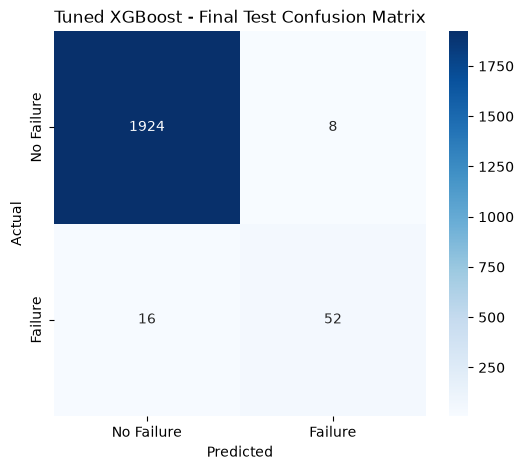

In [121]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    tuned_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.title(
    "Tuned XGBoost - Final Test Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [122]:
final_results = pd.DataFrame([
    logistic_results,

    {
        "Model": "Random Forest",
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1": rf_f1,
        "ROC-AUC": rf_roc_auc,
        "PR-AUC": rf_pr_auc
    },

    xgb_results,

    {
        "Model": "Tuned XGBoost",
        "Accuracy": tuned_accuracy,
        "Precision": tuned_precision,
        "Recall": tuned_recall,
        "F1": tuned_f1,
        "ROC-AUC": tuned_roc_auc,
        "PR-AUC": tuned_pr_auc
    }
])

final_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.8590,0.177711,0.867647,0.295000,0.934006,0.466182
1,Random Forest,0.9895,0.898305,0.779412,0.834646,0.974154,0.857692
2,XGBoost,0.9820,0.686047,0.867647,0.766234,0.978885,0.884490
3,Tuned XGBoost,0.9880,0.866667,0.764706,0.812500,0.972012,0.860887


In [123]:
final_results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.8590,0.1777,0.8676,0.2950,0.9340,0.4662
1,Random Forest,0.9895,0.8983,0.7794,0.8346,0.9742,0.8577
2,XGBoost,0.9820,0.6860,0.8676,0.7662,0.9789,0.8845
3,Tuned XGBoost,0.9880,0.8667,0.7647,0.8125,0.9720,0.8609


In [124]:
print(best_tuned_threshold)
print("Final threshold:", final_tuned_threshold)

Threshold    0.650000
Precision    0.829787
Recall       0.722222
F1           0.772277
Name: 11, dtype: float64
Final threshold: 0.6500000000000001


In [125]:
import shap

In [126]:
final_preprocessor = (
    xgb_validation_model
    .named_steps["preprocessor"]
)

In [127]:
final_classifier = (
    xgb_validation_model
    .named_steps["classifier"]
)

In [128]:
X_test_transformed = final_preprocessor.transform(X_test)

In [129]:
feature_names = (
    final_preprocessor
    .get_feature_names_out()
)

In [130]:
print(len(feature_names))
print(feature_names)

11
['num__Air temperature' 'num__Process temperature' 'num__Rotational speed'
 'num__Torque' 'num__Tool wear' 'num__Temperature Difference'
 'num__Mechanical Power kW' 'num__Temperature Ratio' 'cat__Type_H'
 'cat__Type_L' 'cat__Type_M']


In [131]:
# Extract the final tuned model components
final_preprocessor = (
    best_xgb_model
    .named_steps["preprocessor"]
)

final_classifier = (
    best_xgb_model
    .named_steps["classifier"]
)

# Transform test data using the same preprocessing
X_test_transformed = final_preprocessor.transform(X_test)

# Get transformed feature names
feature_names = (
    final_preprocessor
    .get_feature_names_out()
)

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 11
['num__Air temperature' 'num__Process temperature' 'num__Rotational speed'
 'num__Torque' 'num__Tool wear' 'num__Temperature Difference'
 'num__Mechanical Power kW' 'num__Temperature Ratio' 'cat__Type_H'
 'cat__Type_L' 'cat__Type_M']


In [132]:
explainer = shap.TreeExplainer(
    final_classifier
)

In [133]:
shap_values = explainer.shap_values(
    X_test_transformed
)

In [134]:
print("SHAP shape:", shap_values.shape)

SHAP shape: (2000, 11)


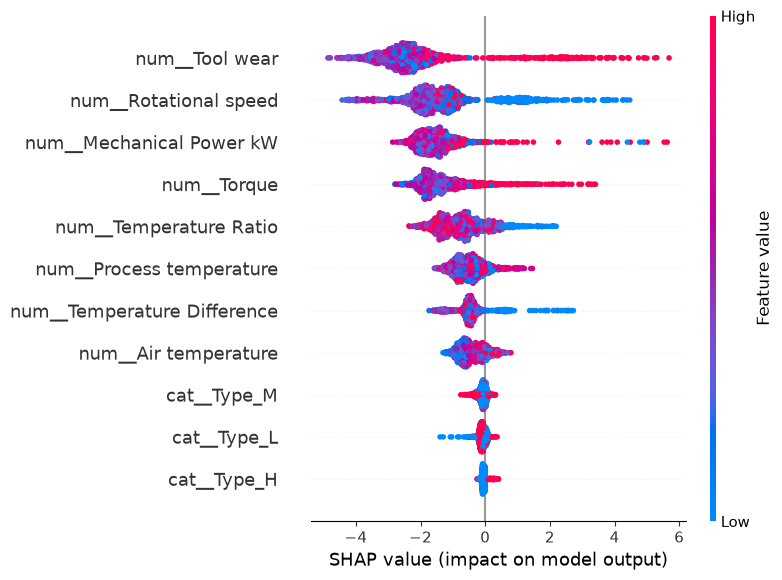

In [135]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

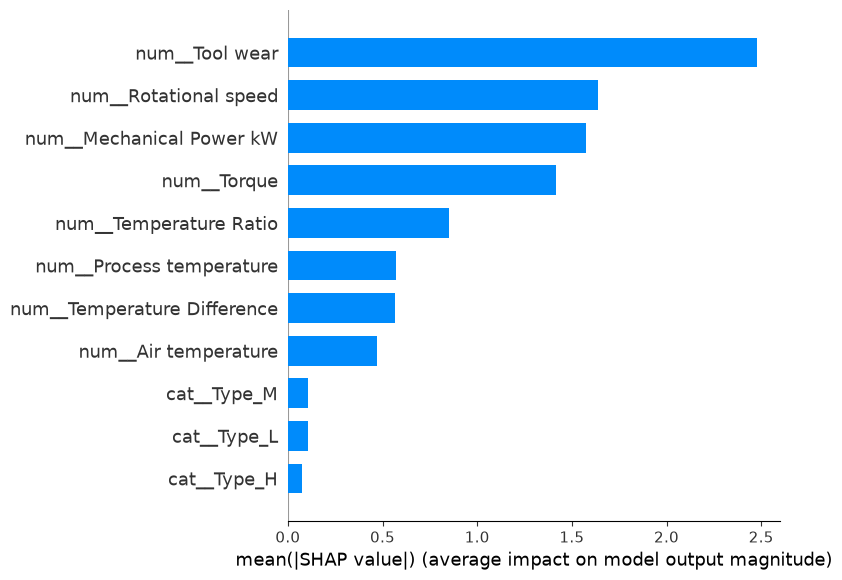

In [136]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

In [137]:
risk_index = np.argmax(final_tuned_threshold if False else tuned_test_proba)

print("Test row:", risk_index)
print(
    "Failure probability:",
    tuned_test_proba[risk_index]
)
print(
    "Actual failure:",
    y_test.iloc[risk_index]
)

Test row: 1949
Failure probability: 0.999869
Actual failure: 1


In [138]:
risk_index = np.argmax(tuned_test_proba)

print("Test row:", risk_index)
print("Failure probability:", tuned_test_proba[risk_index])
print("Actual failure:", y_test.iloc[risk_index])

Test row: 1949
Failure probability: 0.999869
Actual failure: 1


In [139]:
X_test.iloc[risk_index]

Type                             M
Air temperature              301.7
Process temperature          309.8
Rotational speed              1284
Torque                        68.2
Tool wear                      111
Temperature Difference         8.1
Mechanical Power kW       9.170183
Temperature Ratio         1.026848
Name: 4342, dtype: object

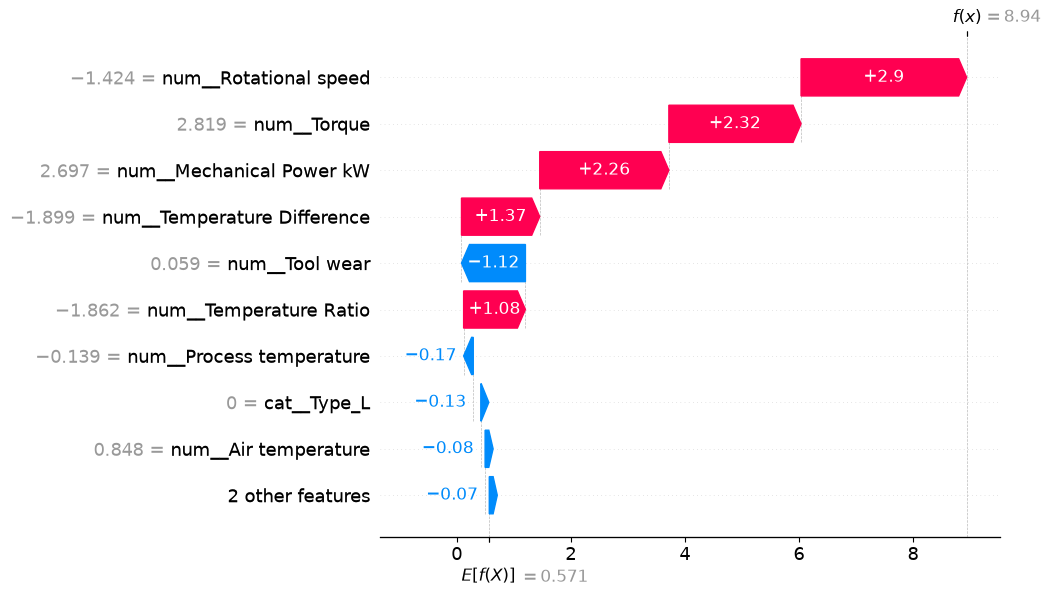

In [140]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[risk_index],
        base_values=explainer.expected_value,
        data=X_test_transformed[risk_index],
        feature_names=feature_names
    )
)

In [141]:
base_value = explainer.expected_value

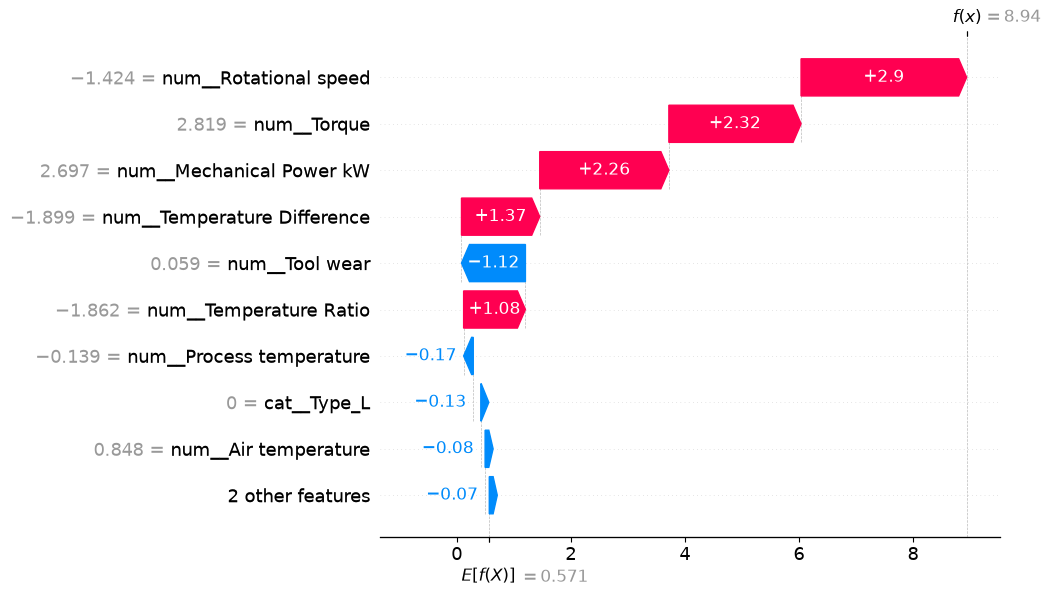

In [142]:
base_value = explainer.expected_value

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[risk_index],
        base_values=base_value,
        data=X_test_transformed[risk_index],
        feature_names=feature_names
    )
)

In [143]:
tuned_test_proba[risk_index]

np.float32(0.999869)

In [144]:
print("Machine index:", risk_index)

print(
    "Failure probability:",
    tuned_test_proba[risk_index]
)

print(
    "Predicted class:",
    tuned_test_pred[risk_index]
)

print(
    "Actual class:",
    y_test.iloc[risk_index]
)

Machine index: 1949
Failure probability: 0.999869
Predicted class: 1
Actual class: 1


In [145]:
def explain_machine(index):
    probability = tuned_test_proba[index]
    prediction = tuned_test_pred[index]
    actual = y_test.iloc[index]

    print(f"Machine/Test Index: {index}")
    print(f"Failure Probability: {probability:.2%}")
    print(
        f"Prediction: "
        f"{'FAILURE RISK' if prediction == 1 else 'NORMAL'}"
    )
    print(
        f"Actual: "
        f"{'FAILURE' if actual == 1 else 'NO FAILURE'}"
    )

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[index],
            base_values=explainer.expected_value,
            data=X_test_transformed[index],
            feature_names=feature_names
        )
    )

Machine/Test Index: 1949
Failure Probability: 99.99%
Prediction: FAILURE RISK
Actual: FAILURE


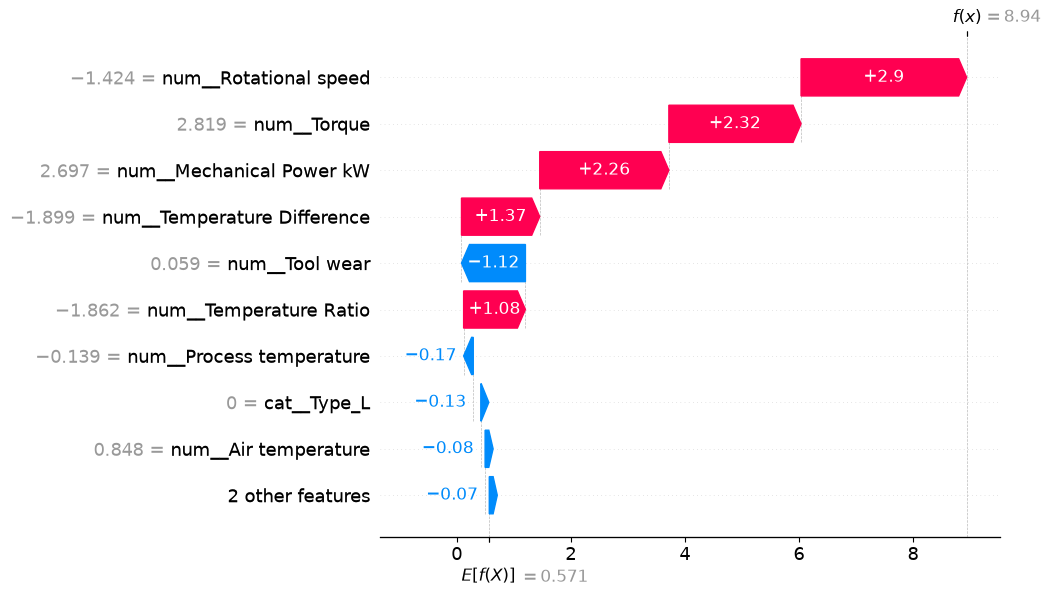

In [146]:
explain_machine(risk_index)

## 12. Anomaly Detection

In [147]:
normal_train_mask = y_train_model == 0

X_normal_train = X_train_model[
    normal_train_mask
]

In [148]:
print("Normal training samples:", X_normal_train.shape)

Normal training samples: (6183, 9)


In [149]:
anomaly_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [150]:
X_normal_train_transformed = (
    anomaly_preprocessor.fit_transform(
        X_normal_train
    )
)

In [151]:
print(
    "Normal training transformed shape:",
    X_normal_train_transformed.shape
)

Normal training transformed shape: (6183, 11)


In [152]:
from sklearn.ensemble import IsolationForest

In [153]:
isolation_forest = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

In [154]:
isolation_forest.fit(
    X_normal_train_transformed
)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [155]:
X_val_transformed_anomaly = (
    anomaly_preprocessor.transform(X_val)
)

X_test_transformed_anomaly = (
    anomaly_preprocessor.transform(X_test)
)

In [156]:
val_anomaly_scores = (
    isolation_forest.decision_function(
        X_val_transformed_anomaly
    )
)

test_anomaly_scores = (
    isolation_forest.decision_function(
        X_test_transformed_anomaly
    )
)

In [157]:
val_anomaly_risk = -val_anomaly_scores
test_anomaly_risk = -test_anomaly_scores

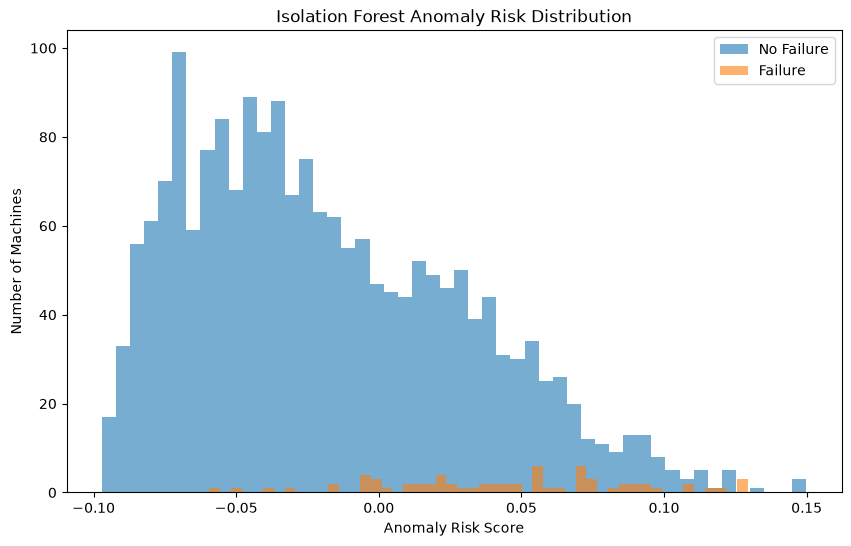

In [158]:
plt.figure(figsize=(10, 6))

plt.hist(
    test_anomaly_risk[y_test.values == 0],
    bins=50,
    alpha=0.6,
    label="No Failure"
)

plt.hist(
    test_anomaly_risk[y_test.values == 1],
    bins=50,
    alpha=0.6,
    label="Failure"
)

plt.xlabel("Anomaly Risk Score")
plt.ylabel("Number of Machines")
plt.title(
    "Isolation Forest Anomaly Risk Distribution"
)

plt.legend()
plt.show()

In [159]:
anomaly_roc_auc = roc_auc_score(
    y_test,
    test_anomaly_risk
)

print(
    "Anomaly Detection ROC-AUC:",
    anomaly_roc_auc
)

Anomaly Detection ROC-AUC: 0.8282715260017051


In [160]:
normal_train_scores = (
    isolation_forest.decision_function(
        X_normal_train_transformed
    )
)

normal_train_risk = -normal_train_scores

In [161]:
np.percentile(
    normal_train_risk,
    [90, 95, 97, 98, 99]
)

array([0.04711136, 0.07102192, 0.08675877, 0.09602934, 0.10934403])

In [162]:
anomaly_threshold = 0.08

In [163]:
test_anomaly_pred = (
    test_anomaly_risk >= anomaly_threshold
).astype(int)

In [164]:
print(
    "Anomalous machines:",
    test_anomaly_pred.sum()
)

print(
    "Total machines:",
    len(test_anomaly_pred)
)

Anomalous machines: 81
Total machines: 2000


In [165]:
anomaly_precision = precision_score(
    y_test,
    test_anomaly_pred,
    zero_division=0
)

anomaly_recall = recall_score(
    y_test,
    test_anomaly_pred,
    zero_division=0
)

anomaly_f1 = f1_score(
    y_test,
    test_anomaly_pred,
    zero_division=0
)

print("Isolation Forest")
print("----------------")
print("Threshold :", anomaly_threshold)
print("Precision :", anomaly_precision)
print("Recall    :", anomaly_recall)
print("F1 Score  :", anomaly_f1)
print("ROC-AUC   :", anomaly_roc_auc)

Isolation Forest
----------------
Threshold : 0.08
Precision : 0.18518518518518517
Recall    : 0.22058823529411764
F1 Score  : 0.20134228187919462
ROC-AUC   : 0.8282715260017051


In [166]:
anomaly_cm = confusion_matrix(
    y_test,
    test_anomaly_pred
)

print(anomaly_cm)

[[1866   66]
 [  53   15]]


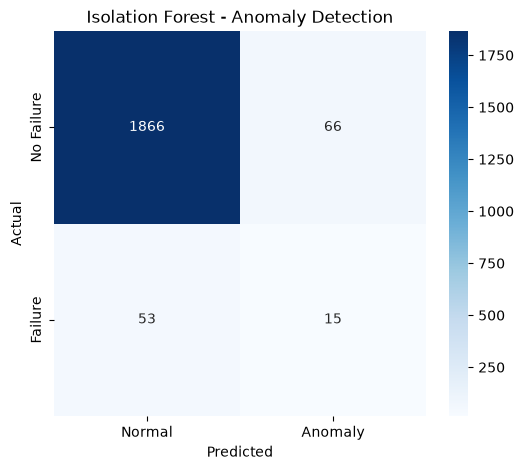

In [167]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    anomaly_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Anomaly"],
    yticklabels=["No Failure", "Failure"]
)

plt.title("Isolation Forest - Anomaly Detection")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [168]:
anomaly_results = {
    "Model": "Isolation Forest",
    "Precision": anomaly_precision,
    "Recall": anomaly_recall,
    "F1": anomaly_f1,
    "ROC-AUC": anomaly_roc_auc
}

anomaly_results

{'Model': 'Isolation Forest',
 'Precision': 0.18518518518518517,
 'Recall': 0.22058823529411764,
 'F1': 0.20134228187919462,
 'ROC-AUC': 0.8282715260017051}

In [169]:
normal_min = normal_train_risk.min()
normal_max = normal_train_risk.max()

test_anomaly_normalized = (
    (test_anomaly_risk - normal_min)
    /
    (normal_max - normal_min)
)

test_anomaly_normalized = np.clip(
    test_anomaly_normalized,
    0,
    1
)

In [170]:
failure_probability = tuned_test_proba

combined_risk = (
    0.70 * failure_probability
    +
    0.30 * test_anomaly_normalized
)

In [171]:
def classify_machine_risk(
    failure_probability,
    anomaly_risk
):
    
    if (
        failure_probability >= final_tuned_threshold
        and anomaly_risk >= anomaly_threshold
    ):
        return "CRITICAL"

    elif failure_probability >= final_tuned_threshold:
        return "PREDICTED FAILURE"

    elif anomaly_risk >= anomaly_threshold:
        return "ANOMALOUS"

    else:
        return "HEALTHY"

In [172]:
risk_states = [
    classify_machine_risk(
        failure_probability[i],
        test_anomaly_risk[i]
    )
    for i in range(len(y_test))
]

In [173]:
pd.Series(risk_states).value_counts()

HEALTHY              1874
ANOMALOUS              66
PREDICTED FAILURE      45
CRITICAL               15
Name: count, dtype: int64

In [174]:
monitoring_df = X_test.copy().reset_index(drop=True)

monitoring_df["Actual Failure"] = y_test.reset_index(drop=True)

monitoring_df["Failure Probability"] = failure_probability

monitoring_df["Anomaly Risk"] = test_anomaly_risk

monitoring_df["Combined Risk"] = combined_risk

monitoring_df["Risk State"] = risk_states

In [175]:
monitoring_df.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Temperature Difference,Mechanical Power kW,Temperature Ratio,Actual Failure,Failure Probability,Anomaly Risk,Combined Risk,Risk State
0,L,300.5,309.8,1345,62.7,153,9.3,8.831174,1.030948,0,0.014172,0.013217,0.128636,HEALTHY
1,L,303.7,312.4,1513,40.1,135,8.7,6.353484,1.028647,0,0.000067,-0.024332,0.079555,HEALTHY
2,L,302.5,311.4,1559,37.6,209,8.9,6.138504,1.029421,0,0.165370,-0.042593,0.176199,HEALTHY
3,H,295.6,306.3,1509,35.8,60,10.7,5.657192,1.036198,0,0.001777,0.079780,0.189463,HEALTHY
4,H,300.5,310.0,1358,60.4,102,9.5,8.589449,1.031614,0,0.000919,0.084465,0.193754,ANOMALOUS


In [176]:
monitoring_df.sort_values(
    "Combined Risk",
    ascending=False
).head(10)

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Temperature Difference,Mechanical Power kW,Temperature Ratio,Actual Failure,Failure Probability,Anomaly Risk,Combined Risk,Risk State
963,H,302.7,310.8,1275,55.0,25,8.1,7.343473,1.026759,1,0.999630,0.129330,0.939699,CRITICAL
666,M,301.0,312.2,2710,9.7,143,11.2,2.752768,1.037209,1,0.992770,0.129423,0.934995,CRITICAL
1949,M,301.7,309.8,1284,68.2,111,8.1,9.170183,1.026848,1,0.999869,0.108406,0.918018,CRITICAL
1045,H,302.8,312.4,1411,53.8,246,9.6,7.949465,1.031704,1,0.980110,0.117608,0.913795,CRITICAL
562,M,301.8,309.9,1334,61.0,182,8.1,8.521465,1.026839,1,0.996232,0.095837,0.902348,CRITICAL
645,L,301.8,310.2,2825,5.8,215,8.4,1.715833,1.027833,1,0.946758,0.128859,0.902197,CRITICAL
779,L,300.5,310.5,2633,12.2,17,10.0,3.363871,1.033278,1,0.991795,0.095121,0.898494,CRITICAL
1745,M,302.6,311.6,1227,68.2,187,9.0,8.763096,1.029742,1,0.993265,0.088226,0.892324,CRITICAL
503,L,301.4,309.9,1259,63.9,20,8.5,8.424715,1.028202,1,0.998960,0.080453,0.888194,CRITICAL
1774,M,302.7,311.1,1297,60.7,125,8.4,8.244366,1.027750,1,0.999180,0.073355,0.880936,PREDICTED FAILURE


In [177]:
def maintenance_action(state):
    
    if state == "CRITICAL":
        return "Immediate inspection"

    elif state == "PREDICTED FAILURE":
        return "Schedule preventive maintenance"

    elif state == "ANOMALOUS":
        return "Inspect operating conditions"

    else:
        return "Continue monitoring"

In [178]:
monitoring_df["Recommended Action"] = (
    monitoring_df["Risk State"]
    .apply(maintenance_action)
)

In [179]:
monitoring_df[
    [
        "Failure Probability",
        "Anomaly Risk",
        "Combined Risk",
        "Risk State",
        "Recommended Action"
    ]
].sort_values(
    "Combined Risk",
    ascending=False
).head(10)

,Failure Probability,Anomaly Risk,Combined Risk,Risk State,Recommended Action
963,0.999630,0.129330,0.939699,CRITICAL,Immediate inspection
666,0.992770,0.129423,0.934995,CRITICAL,Immediate inspection
1949,0.999869,0.108406,0.918018,CRITICAL,Immediate inspection
1045,0.980110,0.117608,0.913795,CRITICAL,Immediate inspection
562,0.996232,0.095837,0.902348,CRITICAL,Immediate inspection
645,0.946758,0.128859,0.902197,CRITICAL,Immediate inspection
779,0.991795,0.095121,0.898494,CRITICAL,Immediate inspection
1745,0.993265,0.088226,0.892324,CRITICAL,Immediate inspection
503,0.998960,0.080453,0.888194,CRITICAL,Immediate inspection
1774,0.999180,0.073355,0.880936,PREDICTED FAILURE,Schedule preventive maintenance


## 13. Hybrid Risk Engine

In [180]:
val_proba = (
    xgb_validation_model.predict_proba(X_val)[:, 1]
)

In [181]:
val_failure_probability = (
    best_xgb_model.predict_proba(X_val)[:, 1]
)

In [182]:
val_anomaly_risk

array([-0.00894985,  0.06612605, -0.0528303 , ..., -0.05613187,
       -0.02640136,  0.02453419], shape=(1600,))

In [183]:
print(
    "Validation anomaly risk range:",
    val_anomaly_risk.min(),
    val_anomaly_risk.max()
)

Validation anomaly risk range: -0.0993061813966597 0.1665187472296159


In [184]:
normal_min = normal_train_risk.min()
normal_max = normal_train_risk.max()

In [185]:
val_anomaly_normalized = (
    (val_anomaly_risk - normal_min)
    /
    (normal_max - normal_min)
)

val_anomaly_normalized = np.clip(
    val_anomaly_normalized,
    0,
    1
)

In [186]:
test_anomaly_normalized = (
    (test_anomaly_risk - normal_min)
    /
    (normal_max - normal_min)
)

test_anomaly_normalized = np.clip(
    test_anomaly_normalized,
    0,
    1
)

In [187]:
weights = np.arange(
    0.5,
    1.01,
    0.05
)

hybrid_results = []

for xgb_weight in weights:

    anomaly_weight = 1 - xgb_weight

    hybrid_score = (
        xgb_weight * val_failure_probability
        +
        anomaly_weight * val_anomaly_normalized
    )

    for threshold in np.arange(
        0.30,
        0.91,
        0.02
    ):

        prediction = (
            hybrid_score >= threshold
        ).astype(int)

        hybrid_results.append({
            "XGB Weight": xgb_weight,
            "Anomaly Weight": anomaly_weight,
            "Threshold": threshold,
            "Precision": precision_score(
                y_val,
                prediction,
                zero_division=0
            ),
            "Recall": recall_score(
                y_val,
                prediction,
                zero_division=0
            ),
            "F1": f1_score(
                y_val,
                prediction,
                zero_division=0
            ),
            "ROC-AUC": roc_auc_score(
                y_val,
                hybrid_score
            ),
            "PR-AUC": average_precision_score(
                y_val,
                hybrid_score
            )
        })

hybrid_results_df = pd.DataFrame(
    hybrid_results
)

In [188]:
best_hybrid = hybrid_results_df.loc[
    hybrid_results_df["F1"].idxmax()
]

best_hybrid

XGB Weight        0.500000
Anomaly Weight    0.500000
Threshold         0.560000
Precision         0.816327
Recall            0.740741
F1                0.776699
ROC-AUC           0.897681
PR-AUC            0.694191
Name: 13, dtype: float64

In [189]:
high_recall_configs = (
    hybrid_results_df[
        hybrid_results_df["Recall"] >= 0.80
    ]
    .sort_values(
        ["Precision", "F1"],
        ascending=False
    )
)

high_recall_configs.head(10)

,XGB Weight,Anomaly Weight,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC
0,0.5,0.5,0.3,0.305556,0.814815,0.444444,0.897681,0.694191


In [190]:
candidate_configs = (
    hybrid_results_df[
        hybrid_results_df["Recall"] >= 0.80
    ]
    .sort_values(
        ["Precision", "F1"],
        ascending=False
    )
)

candidate_configs.head(10)

,XGB Weight,Anomaly Weight,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC
0,0.5,0.5,0.3,0.305556,0.814815,0.444444,0.897681,0.694191


In [191]:
best_xgb_weight = best_hybrid["XGB Weight"]
best_anomaly_weight = best_hybrid["Anomaly Weight"]
best_hybrid_threshold = best_hybrid["Threshold"]

print("Best XGBoost weight:", best_xgb_weight)
print("Best Anomaly weight:", best_anomaly_weight)
print("Best Hybrid threshold:", best_hybrid_threshold)

Best XGBoost weight: 0.5
Best Anomaly weight: 0.5
Best Hybrid threshold: 0.5600000000000003


In [192]:
final_hybrid_score = (
    best_xgb_weight * tuned_test_proba
    +
    best_anomaly_weight * test_anomaly_normalized
)

final_hybrid_pred = (
    final_hybrid_score >= best_hybrid_threshold
).astype(int)

In [193]:
hybrid_accuracy = accuracy_score(
    y_test,
    final_hybrid_pred
)

hybrid_precision = precision_score(
    y_test,
    final_hybrid_pred,
    zero_division=0
)

hybrid_recall = recall_score(
    y_test,
    final_hybrid_pred,
    zero_division=0
)

hybrid_f1 = f1_score(
    y_test,
    final_hybrid_pred,
    zero_division=0
)

hybrid_roc_auc = roc_auc_score(
    y_test,
    final_hybrid_score
)

hybrid_pr_auc = average_precision_score(
    y_test,
    final_hybrid_score
)

print("FINAL HYBRID MODEL")
print("------------------")
print("XGBoost Weight :", best_xgb_weight)
print("Anomaly Weight :", best_anomaly_weight)
print("Threshold      :", best_hybrid_threshold)
print("Accuracy       :", hybrid_accuracy)
print("Precision      :", hybrid_precision)
print("Recall         :", hybrid_recall)
print("F1 Score       :", hybrid_f1)
print("ROC-AUC        :", hybrid_roc_auc)
print("PR-AUC         :", hybrid_pr_auc)

FINAL HYBRID MODEL
------------------
XGBoost Weight : 0.5
Anomaly Weight : 0.5
Threshold      : 0.5600000000000003
Accuracy       : 0.9885
Precision      : 0.8688524590163934
Recall         : 0.7794117647058824
F1 Score       : 0.8217054263565892
ROC-AUC        : 0.9489099987821216
PR-AUC         : 0.818903181295083


In [194]:
final_hybrid_cm = confusion_matrix(
    y_test,
    final_hybrid_pred
)

print(final_hybrid_cm)

[[1924    8]
 [  15   53]]


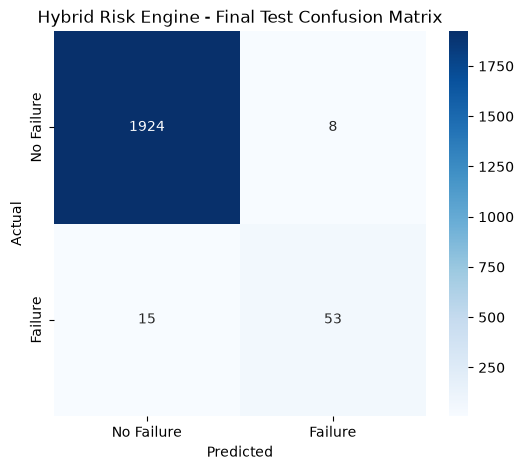

In [195]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    final_hybrid_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.title("Hybrid Risk Engine - Final Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [196]:
final_model_comparison = pd.DataFrame([
    {
        "Model": "Baseline XGBoost",
        "Precision": final_precision,
        "Recall": final_recall,
        "F1": final_f1,
        "ROC-AUC": final_roc_auc,
        "PR-AUC": final_pr_auc
    },
    {
        "Model": "Tuned XGBoost",
        "Precision": tuned_precision,
        "Recall": tuned_recall,
        "F1": tuned_f1,
        "ROC-AUC": tuned_roc_auc,
        "PR-AUC": tuned_pr_auc
    },
    {
        "Model": "Hybrid XGBoost + Isolation Forest",
        "Precision": hybrid_precision,
        "Recall": hybrid_recall,
        "F1": hybrid_f1,
        "ROC-AUC": hybrid_roc_auc,
        "PR-AUC": hybrid_pr_auc
    }
])

final_model_comparison.round(4)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Baseline XGBoost,0.7778,0.8235,0.8000,0.9720,0.8607
1,Tuned XGBoost,0.8667,0.7647,0.8125,0.9720,0.8609
2,Hybrid XGBoost + Isolation Forest,0.8689,0.7794,0.8217,0.9489,0.8189


In [197]:
monitoring_df = X_test.copy().reset_index(drop=True)

monitoring_df["Actual Failure"] = (
    y_test.reset_index(drop=True)
)

monitoring_df["Failure Probability"] = (
    tuned_test_proba
)

monitoring_df["Anomaly Risk"] = (
    test_anomaly_normalized
)

monitoring_df["Hybrid Risk"] = (
    final_hybrid_score
)

monitoring_df["Predicted Failure"] = (
    final_hybrid_pred
)

In [198]:
def final_machine_status(
    hybrid_score,
    failure_probability,
    anomaly_risk
):

    if hybrid_score >= best_hybrid_threshold:

        if (
            failure_probability >= final_tuned_threshold
            and anomaly_risk >= anomaly_threshold
        ):
            return "CRITICAL"

        elif failure_probability >= final_tuned_threshold:
            return "PREDICTED FAILURE"

        else:
            return "ANOMALOUS"

    return "HEALTHY"

In [199]:
final_risk_states = [
    final_machine_status(
        final_hybrid_score[i],
        tuned_test_proba[i],
        test_anomaly_risk[i]
    )
    for i in range(len(y_test))
]

In [200]:
monitoring_df["Risk State"] = final_risk_states

In [201]:
pd.Series(final_risk_states).value_counts()

HEALTHY              1939
PREDICTED FAILURE      45
CRITICAL               15
ANOMALOUS               1
Name: count, dtype: int64

In [202]:
monitoring_df["Recommended Action"] = (
    monitoring_df["Risk State"]
    .apply(maintenance_action)
)

In [203]:
monitoring_df[
    [
        "Failure Probability",
        "Anomaly Risk",
        "Hybrid Risk",
        "Risk State",
        "Recommended Action"
    ]
].sort_values(
    "Hybrid Risk",
    ascending=False
).head(15)

,Failure Probability,Anomaly Risk,Hybrid Risk,Risk State,Recommended Action
963,0.999630,0.799860,0.899745,CRITICAL,Immediate inspection
666,0.992770,0.800186,0.896478,CRITICAL,Immediate inspection
645,0.946758,0.798221,0.872489,CRITICAL,Immediate inspection
1045,0.980110,0.759062,0.869586,CRITICAL,Immediate inspection
1949,0.999869,0.727031,0.863450,CRITICAL,Immediate inspection
562,0.996232,0.683284,0.839758,CRITICAL,Immediate inspection
779,0.991795,0.680791,0.836293,CRITICAL,Immediate inspection
1745,0.993265,0.656793,0.825029,CRITICAL,Immediate inspection
503,0.998960,0.629741,0.814350,CRITICAL,Immediate inspection
524,0.964024,0.663731,0.813877,CRITICAL,Immediate inspection


In [204]:
final_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Precision": logistic_results["Precision"],
        "Recall": logistic_results["Recall"],
        "F1": logistic_results["F1"],
        "ROC-AUC": logistic_results["ROC-AUC"],
        "PR-AUC": logistic_results["PR-AUC"]
    },
    {
        "Model": "Random Forest",
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1": rf_f1,
        "ROC-AUC": rf_roc_auc,
        "PR-AUC": rf_pr_auc
    },
    {
        "Model": "Tuned XGBoost",
        "Precision": tuned_precision,
        "Recall": tuned_recall,
        "F1": tuned_f1,
        "ROC-AUC": tuned_roc_auc,
        "PR-AUC": tuned_pr_auc
    },
    {
        "Model": "Hybrid XGBoost + Isolation Forest",
        "Precision": hybrid_precision,
        "Recall": hybrid_recall,
        "F1": hybrid_f1,
        "ROC-AUC": hybrid_roc_auc,
        "PR-AUC": hybrid_pr_auc
    }
])

final_results.round(4)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.1777,0.8676,0.2950,0.9340,0.4662
1,Random Forest,0.8983,0.7794,0.8346,0.9742,0.8577
2,Tuned XGBoost,0.8667,0.7647,0.8125,0.9720,0.8609
3,Hybrid XGBoost + Isolation Forest,0.8689,0.7794,0.8217,0.9489,0.8189


## 14. Feature Ablation Study

In [205]:
original_features = [
    "Type",
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear"
]

engineered_features = [
    "Type",
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear",
    "Temperature Difference",
    "Mechanical Power kW",
    "Temperature Ratio"
]

In [206]:
print("Original features:", len(original_features))
print("Engineered features:", len(engineered_features))

Original features: 6
Engineered features: 9


In [207]:
X_train_original = X_train_model[
    original_features
]

X_val_original = X_val[
    original_features
]

X_test_original = X_test[
    original_features
]

In [208]:
print(X_train_original.shape)
print(X_val_original.shape)
print(X_test_original.shape)

(6400, 6)
(1600, 6)
(2000, 6)


In [209]:
original_numerical_features = [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear"
]

original_categorical_features = [
    "Type"
]

In [210]:
original_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            original_numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            original_categorical_features
        )
    ]
)

In [211]:
original_xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            original_preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.08,
                min_child_weight=1,
                subsample=0.9,
                colsample_bytree=0.8,
                gamma=0,
                reg_alpha=0.1,
                reg_lambda=2,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [212]:
original_xgb_model.fit(
    X_train_original,
    y_train_model
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Type','Air temperature','Process temperature','Rotational speed', 'Torque','Tool wear']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder=

In [213]:
original_val_proba = (
    original_xgb_model
    .predict_proba(X_val_original)[:, 1]
)

original_test_proba = (
    original_xgb_model
    .predict_proba(X_test_original)[:, 1]
)

In [214]:
ablation_thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

ablation_results = []

for threshold in ablation_thresholds:

    predictions = (
        original_val_proba >= threshold
    ).astype(int)

    ablation_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_val,
            predictions,
            zero_division=0
        )
    })

ablation_threshold_df = pd.DataFrame(
    ablation_results
)

In [215]:
best_ablation_threshold = (
    ablation_threshold_df.loc[
        ablation_threshold_df["F1"].idxmax()
    ]
)

best_ablation_threshold

Threshold    0.350000
Precision    0.833333
Recall       0.648148
F1           0.729167
Name: 5, dtype: float64

In [216]:
original_threshold = (
    best_ablation_threshold["Threshold"]
)

original_test_pred = (
    original_test_proba >= original_threshold
).astype(int)

In [217]:
original_accuracy = accuracy_score(
    y_test,
    original_test_pred
)

original_precision = precision_score(
    y_test,
    original_test_pred,
    zero_division=0
)

original_recall = recall_score(
    y_test,
    original_test_pred,
    zero_division=0
)

original_f1 = f1_score(
    y_test,
    original_test_pred,
    zero_division=0
)

original_roc_auc = roc_auc_score(
    y_test,
    original_test_proba
)

original_pr_auc = average_precision_score(
    y_test,
    original_test_proba
)

In [218]:
print("ORIGINAL FEATURES XGBOOST")
print("-------------------------")
print("Threshold :", original_threshold)
print("Accuracy  :", original_accuracy)
print("Precision :", original_precision)
print("Recall    :", original_recall)
print("F1 Score  :", original_f1)
print("ROC-AUC   :", original_roc_auc)
print("PR-AUC    :", original_pr_auc)

ORIGINAL FEATURES XGBOOST
-------------------------
Threshold : 0.3500000000000001
Accuracy  : 0.984
Precision : 0.8103448275862069
Recall    : 0.6911764705882353
F1 Score  : 0.746031746031746
ROC-AUC   : 0.969309462915601
PR-AUC    : 0.810951844658463


In [219]:
ablation_comparison = pd.DataFrame([
    {
        "Feature Set": "Original Features",
        "Features": 6,
        "Threshold": original_threshold,
        "Precision": original_precision,
        "Recall": original_recall,
        "F1": original_f1,
        "ROC-AUC": original_roc_auc,
        "PR-AUC": original_pr_auc
    },
    {
        "Feature Set": "Engineered Features",
        "Features": 9,
        "Threshold": final_tuned_threshold,
        "Precision": tuned_precision,
        "Recall": tuned_recall,
        "F1": tuned_f1,
        "ROC-AUC": tuned_roc_auc,
        "PR-AUC": tuned_pr_auc
    }
])

ablation_comparison.round(4)

,Feature Set,Features,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Original Features,6,0.35,0.8103,0.6912,0.7460,0.9693,0.8110
1,Engineered Features,9,0.65,0.8667,0.7647,0.8125,0.9720,0.8609


In [220]:
f1_improvement = (
    engineered_f1 := tuned_f1
) - original_f1

roc_auc_improvement = (
    tuned_roc_auc - original_roc_auc
)

pr_auc_improvement = (
    tuned_pr_auc - original_pr_auc
)

print("F1 improvement:", f1_improvement)
print("ROC-AUC improvement:", roc_auc_improvement)
print("PR-AUC improvement:", pr_auc_improvement)

F1 improvement: 0.06646825396825395
ROC-AUC improvement: 0.0027021678236511804
PR-AUC improvement: 0.04993496037074241


In [221]:
import joblib
import json
import os

In [222]:
print(type(best_xgb_model))

<class 'sklearn.pipeline.Pipeline'>


In [223]:
print(type(isolation_forest))

<class 'sklearn.ensemble._iforest.IsolationForest'>


In [224]:
print(type(anomaly_preprocessor))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [225]:
print("XGBoost threshold:", final_tuned_threshold)
print("Hybrid XGBoost weight:", best_xgb_weight)
print("Hybrid anomaly weight:", best_anomaly_weight)
print("Hybrid threshold:", best_hybrid_threshold)
print("Anomaly threshold:", anomaly_threshold)

XGBoost threshold: 0.6500000000000001
Hybrid XGBoost weight: 0.5
Hybrid anomaly weight: 0.5
Hybrid threshold: 0.5600000000000003
Anomaly threshold: 0.08


In [226]:
os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_xgb_model,
    "../models/xgboost_model.joblib"
)

print("XGBoost model saved successfully.")

XGBoost model saved successfully.


In [227]:
joblib.dump(
    isolation_forest,
    "../models/isolation_forest.joblib"
)

print("Isolation Forest saved successfully.")

Isolation Forest saved successfully.


In [228]:
joblib.dump(
    anomaly_preprocessor,
    "../models/anomaly_preprocessor.joblib"
)

print("Anomaly preprocessor saved successfully.")

Anomaly preprocessor saved successfully.


In [229]:
model_config = {
    "xgb_threshold": float(final_tuned_threshold),

    "hybrid_xgb_weight": float(best_xgb_weight),

    "hybrid_anomaly_weight": float(best_anomaly_weight),

    "hybrid_threshold": float(best_hybrid_threshold),

    "anomaly_threshold": float(anomaly_threshold),

    "normal_anomaly_min": float(normal_min),

    "normal_anomaly_max": float(normal_max),

    "features": engineered_features
}

model_config

{'xgb_threshold': 0.6500000000000001,
 'hybrid_xgb_weight': 0.5,
 'hybrid_anomaly_weight': 0.5,
 'hybrid_threshold': 0.5600000000000003,
 'anomaly_threshold': 0.08,
 'normal_anomaly_min': -0.10047553626330141,
 'normal_anomaly_max': 0.18683157279182172,
 'features': ['Type',
  'Air temperature',
  'Process temperature',
  'Rotational speed',
  'Torque',
  'Tool wear',
  'Temperature Difference',
  'Mechanical Power kW',
  'Temperature Ratio']}

In [230]:
with open(
    "../models/model_config.json",
    "w"
) as f:
    json.dump(
        model_config,
        f,
        indent=4
    )

print("Model configuration saved successfully.")

Model configuration saved successfully.


In [231]:
print(os.listdir("../models"))

['anomaly_preprocessor.joblib', 'isolation_forest.joblib', 'model_config.json', 'xgboost_model.joblib']


In [232]:
import joblib
import json

loaded_xgb = joblib.load(
    "../models/xgboost_model.joblib"
)

loaded_isolation_forest = joblib.load(
    "../models/isolation_forest.joblib"
)

loaded_anomaly_preprocessor = joblib.load(
    "../models/anomaly_preprocessor.joblib"
)

with open(
    "../models/model_config.json",
    "r"
) as f:
    loaded_config = json.load(f)

print("XGBoost:", type(loaded_xgb))
print("Isolation Forest:", type(loaded_isolation_forest))
print("Anomaly Preprocessor:", type(loaded_anomaly_preprocessor))
print("Configuration:", loaded_config)

XGBoost: <class 'sklearn.pipeline.Pipeline'>
Isolation Forest: <class 'sklearn.ensemble._iforest.IsolationForest'>
Anomaly Preprocessor: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Configuration: {'xgb_threshold': 0.6500000000000001, 'hybrid_xgb_weight': 0.5, 'hybrid_anomaly_weight': 0.5, 'hybrid_threshold': 0.5600000000000003, 'anomaly_threshold': 0.08, 'normal_anomaly_min': -0.10047553626330141, 'normal_anomaly_max': 0.18683157279182172, 'features': ['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Temperature Difference', 'Mechanical Power kW', 'Temperature Ratio']}


In [233]:
sample = X_test.iloc[[0]]

loaded_probability = (
    loaded_xgb.predict_proba(sample)[0, 1]
)

print(
    "Loaded model failure probability:",
    loaded_probability
)

Loaded model failure probability: 0.014172127


In [234]:
original_probability = (
    best_xgb_model.predict_proba(sample)[0, 1]
)

print(
    "Original model failure probability:",
    original_probability
)

Original model failure probability: 0.014172127
